This script explores patterns in the data

In [3]:
import pandas as pd

# Load the CSV
df = pd.read_csv("../data/processed/csv_output/Jobs.csv")

In [4]:
df.head()

,UUID,JobID,ArrayID,JobName,IsArray,Interactive,Preempted,Account,User,Constraints,...,Nodes,NodeList,CPUs,Memory,GPUs,GPUType,GPUMemUsage,GPUComputeUsage,CPUMemUsage,CPUComputeUsage
0,'28500523017388652451738865260',28500523,NaN,5140_nr,False,NaN,False,pi_mraessi_umassd_edu,kgupta3_umassd_edu,"['\'amd1900x\'', '\'amd7402\'', '\'amd7502\'',...",...,umd-cscdr-cpu[003-010],"[umd-cscdr-cpu003, umd-cscdr-cpu004, umd-cscdr...",441,661500,NaN,NaN,0.0,0.0,1.006585e+11,14.494155
1,'28519169017389527551738952757',28519169,NaN,250pppfnvt,False,NaN,False,pi_mmayes_umassd_edu,mjamal_umassd_edu,"['\'avx512\'', '\'amd1900x\'', '\'amd7402\'', ...",...,umd-cscdr-cpu[022-023],"[umd-cscdr-cpu022, umd-cscdr-cpu023]",128,131072,NaN,NaN,0.0,0.0,7.296860e+08,0.781196
2,'28600142017393197271739334335',28600142,NaN,spectral_lines,False,NaN,False,pi_nsk_umass_edu,lyang_umass_edu,"['\'amd1900x\'', '\'amd7402\'', '\'amd7502\'',...",...,"cpu[069,073,076-078]","[cpu069, cpu073, cpu076, cpu077, cpu078]",10,2560000,NaN,NaN,0.0,0.0,3.263569e+11,8.240410
3,'28958081017395470261739998627',28958081,NaN,quarterly-updates,False,NaN,False,root,root,NaN,...,cpu073,[cpu073],192,196608,NaN,NaN,0.0,0.0,5.284716e+09,0.390863
4,'28958084017395470261739998627',28958084,NaN,quarterly-updates,False,NaN,False,root,root,NaN,...,cpu076,[cpu076],192,196608,NaN,NaN,0.0,0.0,5.386953e+09,0.439131


In [5]:


# Filter for jobs that requested GPUs
gpu_jobs = df[df['GPUs'] > 0]

# Group by Account (PI group)
pi_group_counts = gpu_jobs['Account'].value_counts()
print("Top PI groups requesting GPUs:")
print(pi_group_counts.head(10))

# Group by GPUType
gpu_type_counts = gpu_jobs['GPUType'].value_counts()
print("\nMost requested GPU types:")
print(gpu_type_counts.head(10))

# Group by User
user_counts = gpu_jobs['User'].value_counts()
print("\nTop users requesting GPUs:")
print(user_counts.head(10))

# Optionally, group by Partition
partition_counts = gpu_jobs['Partition'].value_counts()
print("\nPartitions used for GPU jobs:")
print(partition_counts)

Top PI groups requesting GPUs:
Account
pi_pchien_umass_edu         4458
pi_jdomke_umass_edu         2051
pi_bioch642_umass_edu        961
pi_bo_sheng_umb_edu          507
pi_miyyer_umass_edu          396
pi_ahoumansadr_umass_edu     263
pi_jianhanc_umass_edu        177
pi_smaji_umass_edu           174
pi_sunghoonlee_umass_edu     150
pi_zhuzhang_uri_edu          146
Name: count, dtype: int64

Most requested GPU types:
GPUType
[l40s]        3573
[1080_ti]     2205
[a100]        1372
[titan_x]     1109
[a40]          870
[2080_ti]      799
[m40]          728
[v100]         617
[h100]          59
[rtx_8000]      52
Name: count, dtype: int64

Top users requesting GPUs:
User
pchien_umass_edu         4458
joohwanko_umass_edu      2051
emccleary_umass_edu       961
allen_yang001_umb_edu     507
yekyungkim_umass_edu      280
jroh_umass_edu            216
shanlongli_umass_edu      177
limr_iastate_edu          146
tlanghorst_umass_edu      144
rdaroya_umass_edu         113
Name: count, dtype: i

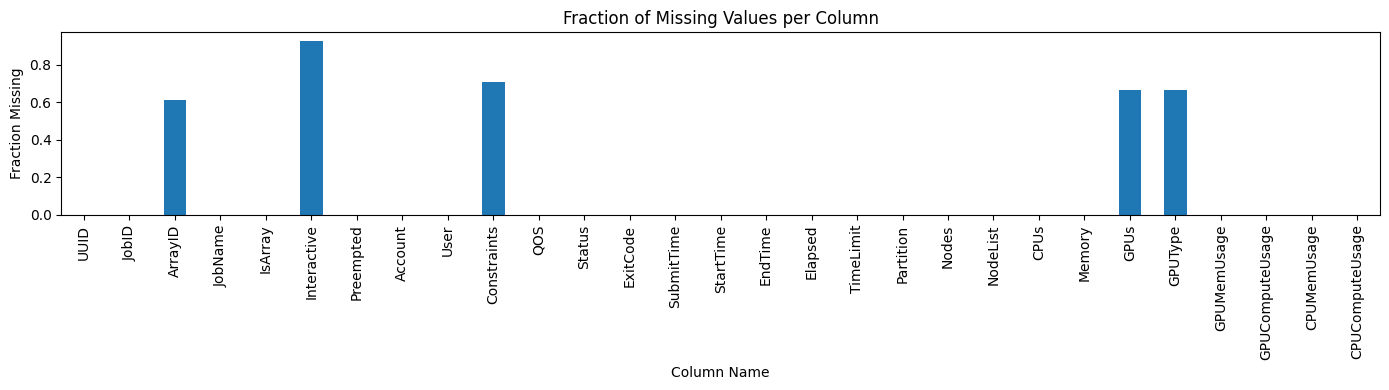

In [6]:
import matplotlib.pyplot as plt

df.isnull().mean().plot(kind='bar', figsize=(14, 4), title='Fraction of Missing Values per Column')
plt.ylabel('Fraction Missing')
plt.xlabel('Column Name')
plt.tight_layout()
plt.show()

## Why the Missing values?
We see that, there are missing values in features su

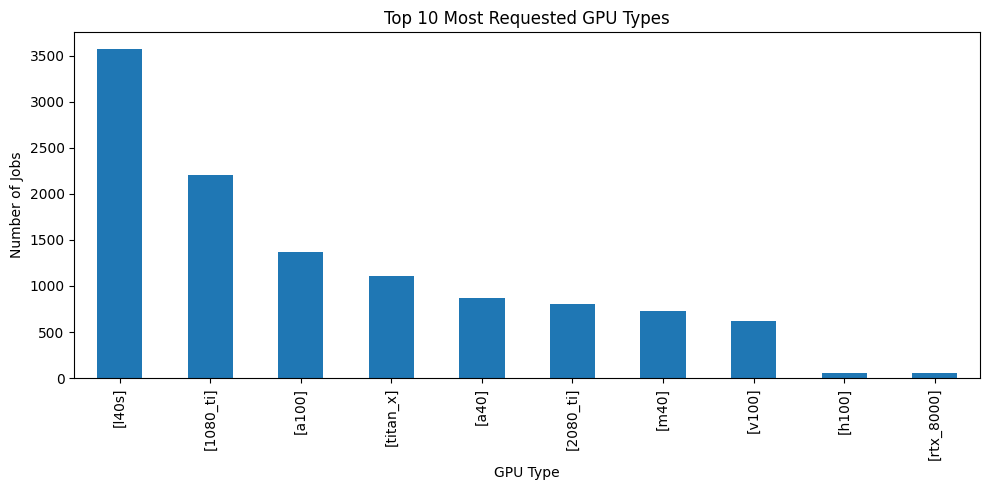

In [7]:
# Visualize the top 10 most requested GPU types
gpu_type_counts.head(10).plot(kind='bar', figsize=(10, 5), title='Top 10 Most Requested GPU Types')
plt.ylabel('Number of Jobs')
plt.xlabel('GPU Type')
plt.tight_layout()
plt.show()


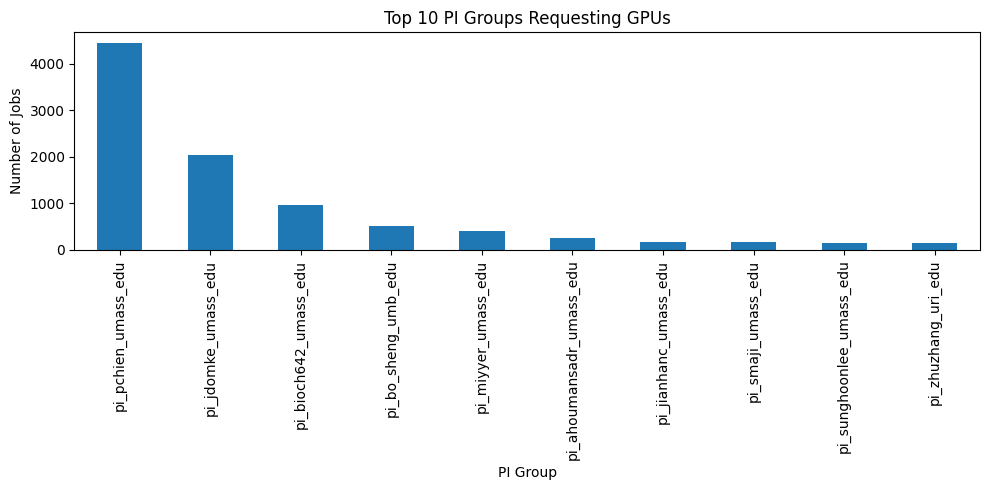

In [8]:

# Visualize the top 10 PI groups requesting GPUs
pi_group_counts.head(10).plot(kind='bar', figsize=(10, 5), title='Top 10 PI Groups Requesting GPUs')
plt.ylabel('Number of Jobs')
plt.xlabel('PI Group')
plt.tight_layout()
plt.show()


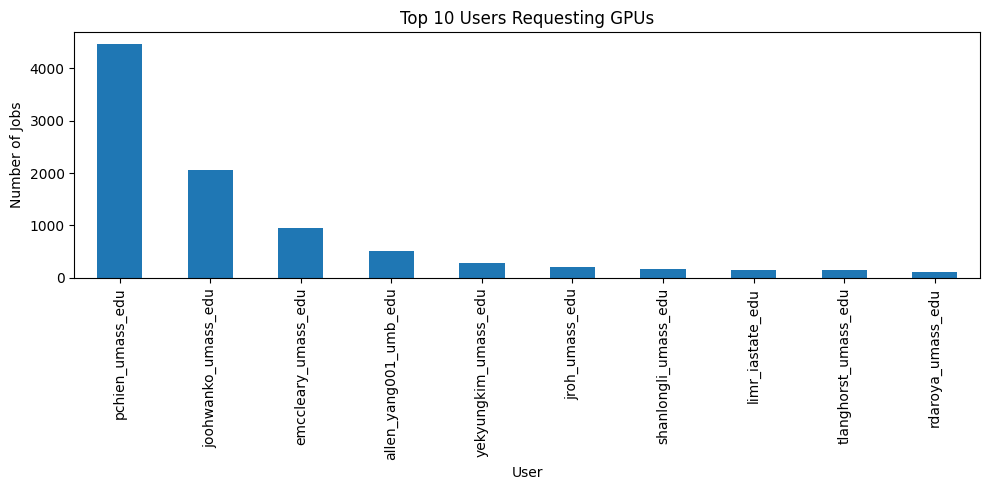

In [9]:

# Visualize the top 10 users requesting GPUs
user_counts.head(10).plot(kind='bar', figsize=(10, 5), title='Top 10 Users Requesting GPUs')
plt.ylabel('Number of Jobs')
plt.xlabel('User')
plt.tight_layout()
plt.show()


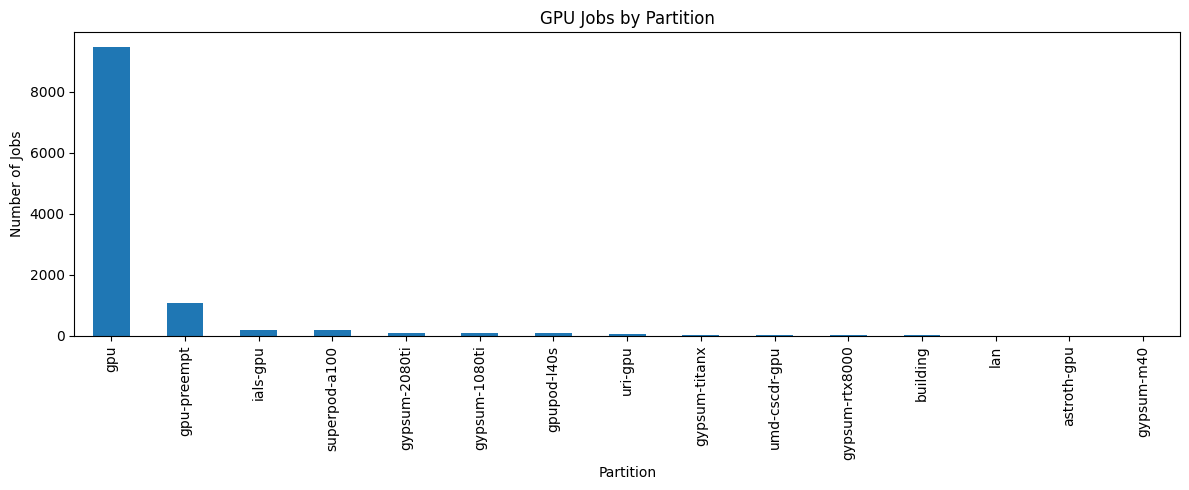

In [10]:

# Visualize the distribution of GPU jobs across partitions
partition_counts.plot(kind='bar', figsize=(12, 5), title='GPU Jobs by Partition')
plt.ylabel('Number of Jobs')
plt.xlabel('Partition')
plt.tight_layout()
plt.show()

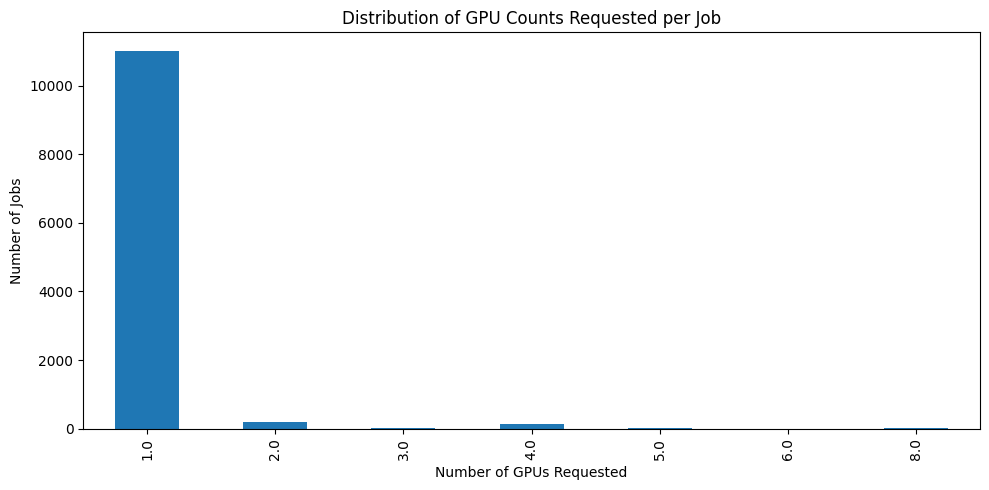

In [11]:
# Visualize the distribution of GPU counts requested per job
gpu_jobs['GPUs'].value_counts().sort_index().plot(kind='bar', figsize=(10, 5), title='Distribution of GPU Counts Requested per Job')
plt.ylabel('Number of Jobs')
plt.xlabel('Number of GPUs Requested')
plt.tight_layout()
plt.show()

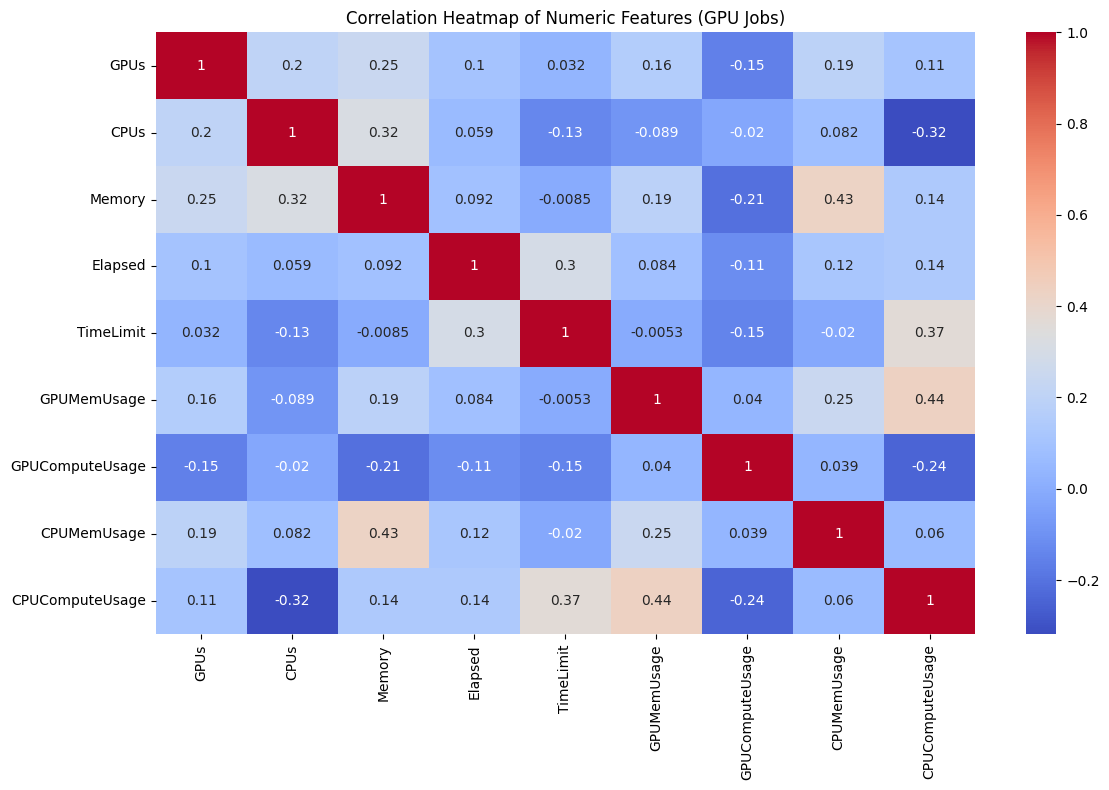

In [12]:
import seaborn as sns

# 1. Heatmap: Correlation between numeric features for GPU jobs
plt.figure(figsize=(12, 8))
sns.heatmap(gpu_jobs[['GPUs', 'CPUs', 'Memory', 'Elapsed', 'TimeLimit', 'GPUMemUsage', 'GPUComputeUsage', 'CPUMemUsage', 'CPUComputeUsage']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features (GPU Jobs)')
plt.tight_layout()
plt.show()


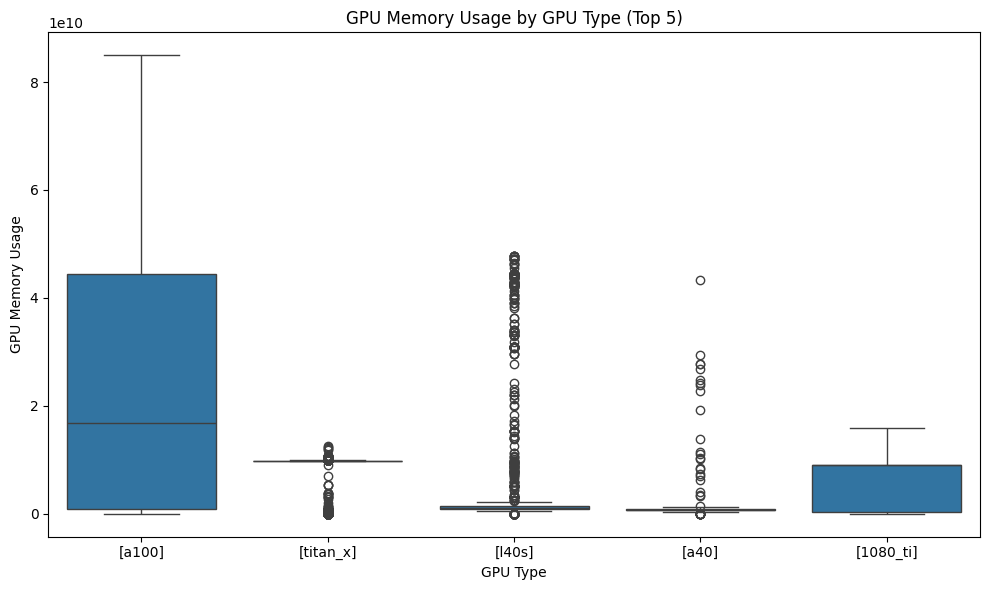

In [13]:

# 2. Boxplot: GPU Memory Usage by GPU Type (top 5 types)
top_gpu_types = gpu_jobs['GPUType'].value_counts().head(5).index
plt.figure(figsize=(10, 6))
sns.boxplot(data=gpu_jobs[gpu_jobs['GPUType'].isin(top_gpu_types)], x='GPUType', y='GPUMemUsage')
plt.title('GPU Memory Usage by GPU Type (Top 5)')
plt.ylabel('GPU Memory Usage')
plt.xlabel('GPU Type')
plt.tight_layout()
plt.show()


/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10963/3146824118.py:4: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=gpu_jobs[gpu_jobs['Partition'].isin(top_partitions)], x='Partition', y='Elapsed', scale='width', inner='quartile')


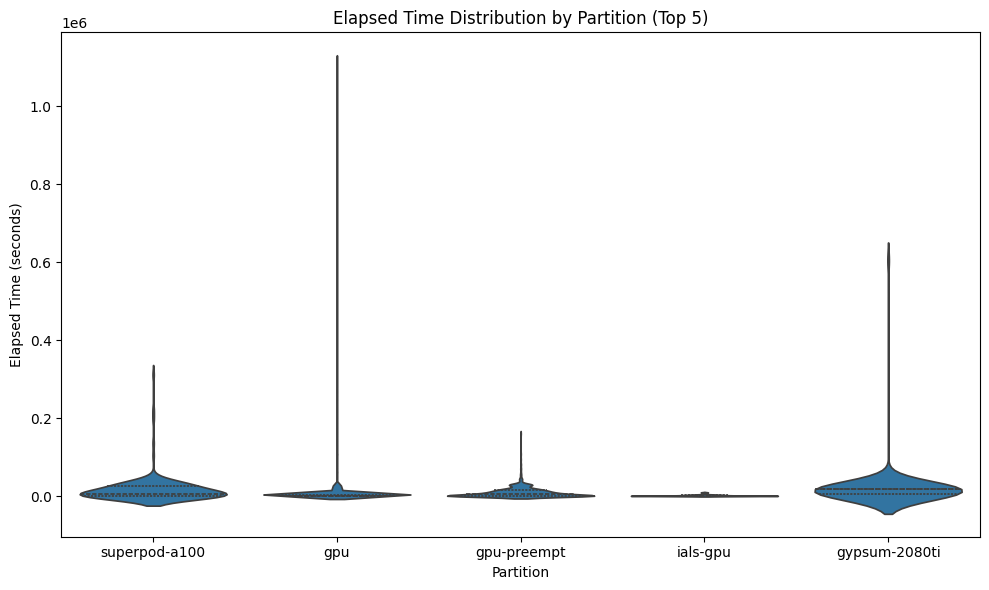

In [14]:

# 3. Violin plot: Elapsed time distribution by Partition (top 5 partitions)
top_partitions = gpu_jobs['Partition'].value_counts().head(5).index
plt.figure(figsize=(10, 6))
sns.violinplot(data=gpu_jobs[gpu_jobs['Partition'].isin(top_partitions)], x='Partition', y='Elapsed', scale='width', inner='quartile')
plt.title('Elapsed Time Distribution by Partition (Top 5)')
plt.ylabel('Elapsed Time (seconds)')
plt.xlabel('Partition')
plt.tight_layout()
plt.show()


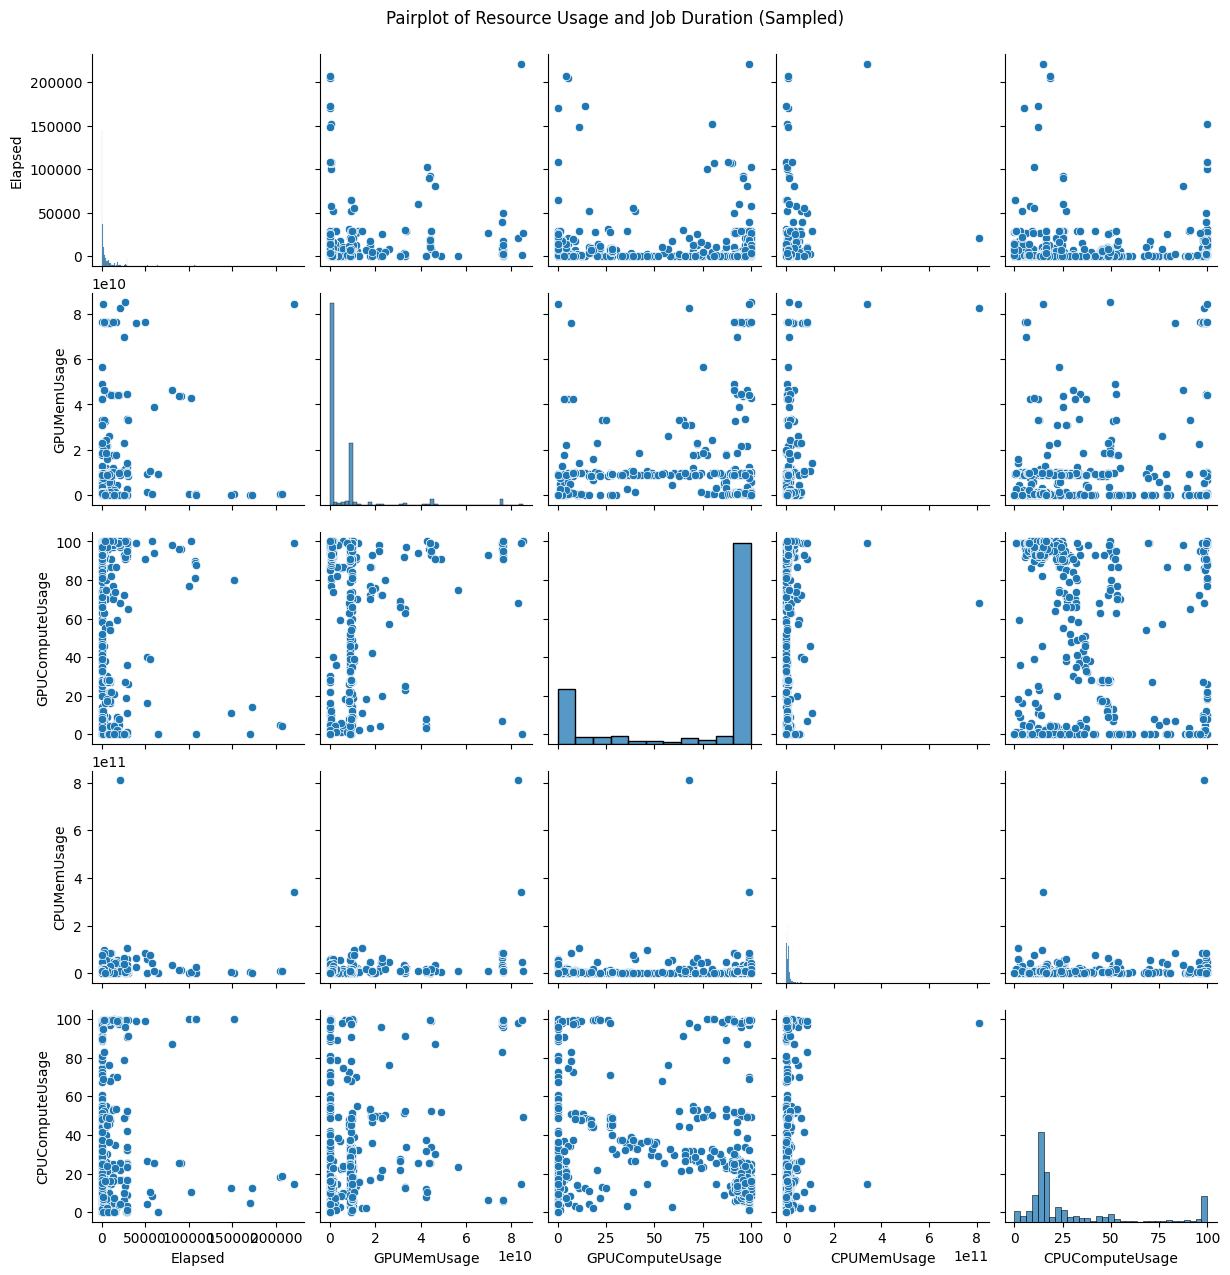

In [15]:

# 4. Pairplot: Relationship between resource usage and job duration (sample for speed)
sampled = gpu_jobs.sample(n=1000, random_state=42) if len(gpu_jobs) > 1000 else gpu_jobs
sns.pairplot(sampled, vars=['Elapsed', 'GPUMemUsage', 'GPUComputeUsage', 'CPUMemUsage', 'CPUComputeUsage'])
plt.suptitle('Pairplot of Resource Usage and Job Duration (Sampled)', y=1.02)
plt.show()

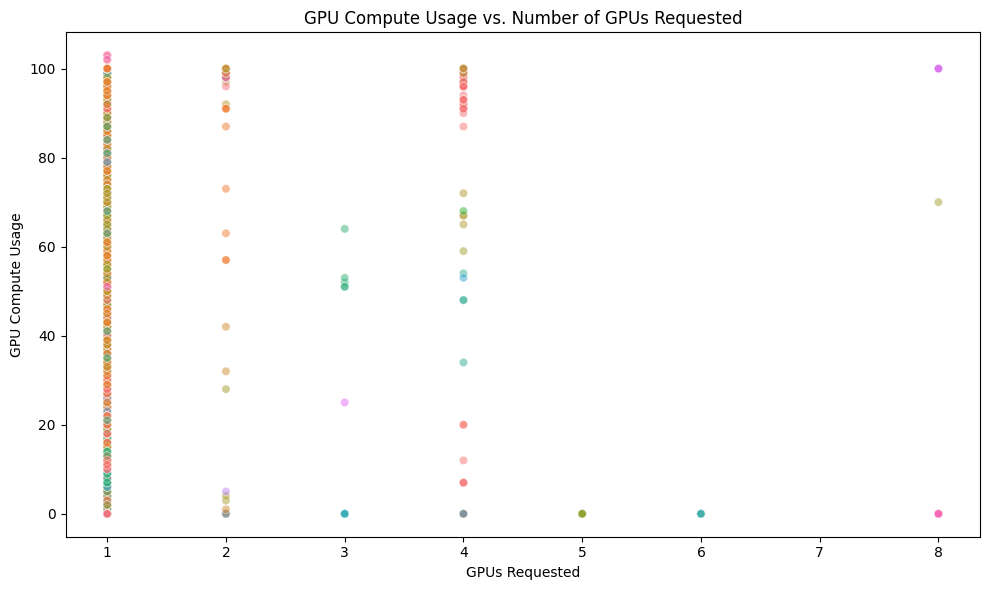

In [16]:
# Visualizations to help flag users who requested GPUs but are underutilizing

# 1. Scatter plot: GPUComputeUsage vs. GPUs requested (per user)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=gpu_jobs, x='GPUs', y='GPUComputeUsage', hue='User', legend=False, alpha=0.5)
plt.title('GPU Compute Usage vs. Number of GPUs Requested')
plt.xlabel('GPUs Requested')
plt.ylabel('GPU Compute Usage')
plt.tight_layout()
plt.show()


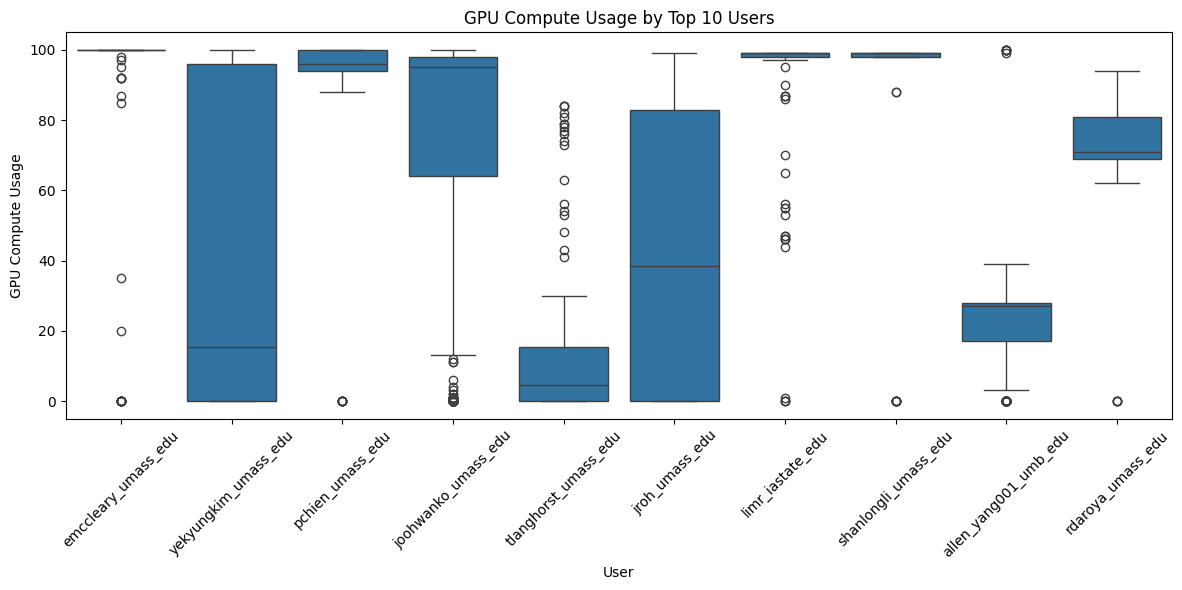

In [17]:

# 2. Boxplot: GPUComputeUsage by User (top 10 users)
top10_users = user_counts.head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=gpu_jobs[gpu_jobs['User'].isin(top10_users)], x='User', y='GPUComputeUsage')
plt.title('GPU Compute Usage by Top 10 Users')
plt.ylabel('GPU Compute Usage')
plt.xlabel('User')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


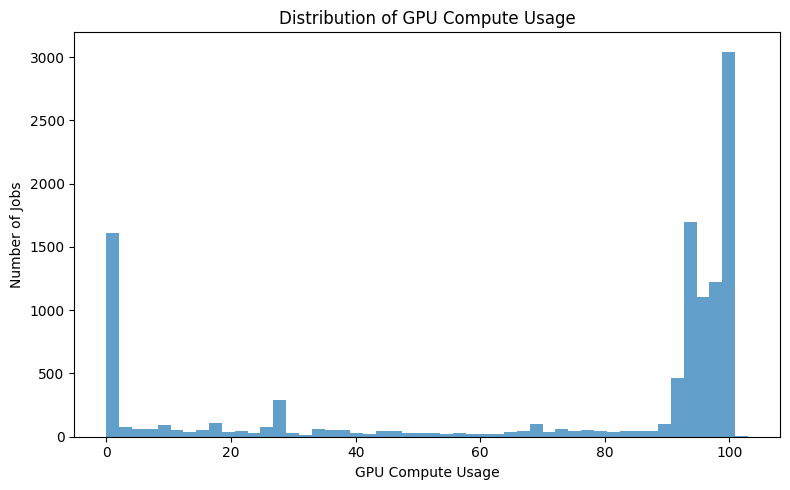

In [18]:

# 3. Histogram: Distribution of GPUComputeUsage (all jobs)
plt.figure(figsize=(8, 5))
gpu_jobs['GPUComputeUsage'].plot(kind='hist', bins=50, alpha=0.7)
plt.title('Distribution of GPU Compute Usage')
plt.xlabel('GPU Compute Usage')
plt.ylabel('Number of Jobs')
plt.tight_layout()
plt.show()


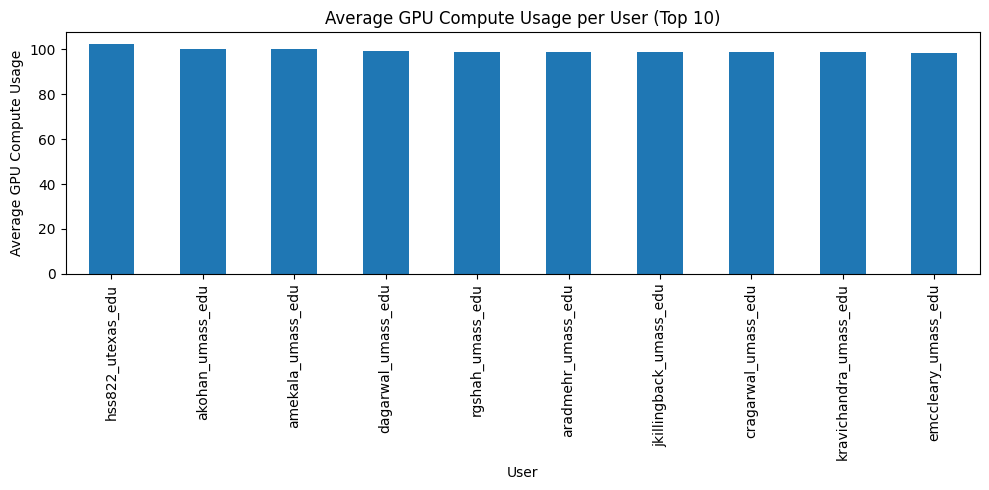

In [19]:

# 4. Bar plot: Average GPUComputeUsage per user (top 10 users)
avg_gpu_util = gpu_jobs.groupby('User')['GPUComputeUsage'].mean().sort_values(ascending=False).head(10)
avg_gpu_util.plot(kind='bar', figsize=(10, 5), title='Average GPU Compute Usage per User (Top 10)')
plt.ylabel('Average GPU Compute Usage')
plt.xlabel('User')
plt.tight_layout()
plt.show()

## preprocessing Data for clustering

In [21]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Prepare the data for clustering: use average GPU compute usage per user
user_gpu_util = avg_gpu_util.values.reshape(-1, 1)

# Scale the data between 0 and 1
scaler = MinMaxScaler()
user_gpu_util_scaled = scaler.fit_transform(user_gpu_util)

# Define thresholds for underutilize, moderate, and full usage
# (e.g., <0.33: underutilize, 0.33-0.66: moderate, >0.66: full usage)
usage_labels = np.where(user_gpu_util_scaled < 0.33, 'Underutilize',
                np.where(user_gpu_util_scaled < 0.66, 'Moderate', 'Full'))

# Create a DataFrame with user, avg usage, and usage group
user_clustering = avg_gpu_util.reset_index()
user_clustering['UsageGroup'] = usage_labels

user_clustering.head(10)

,User,GPUComputeUsage,UsageGroup
0,hss822_utexas_edu,102.500000,Full
1,akohan_umass_edu,100.000000,Moderate
2,amekala_umass_edu,100.000000,Moderate
3,dagarwal_umass_edu,99.500000,Underutilize
4,rgshah_umass_edu,99.000000,Underutilize
5,aradmehr_umass_edu,99.000000,Underutilize
6,jkillingback_umass_edu,99.000000,Underutilize
7,cragarwal_umass_edu,99.000000,Underutilize
8,kravichandra_umass_edu,99.000000,Underutilize
9,emccleary_umass_edu,98.423517,Underutilize


Explore groupings in the data except the one already there

In [22]:
from sklearn.ensemble import RandomForestClassifier

# Prepare data: label jobs as underutilized if GPUComputeUsage is below a threshold (e.g., <33% of max)
threshold = gpu_jobs['GPUComputeUsage'].max() * 0.33
gpu_jobs['UnderutilizeFlag'] = (gpu_jobs['GPUComputeUsage'] < threshold).astype(int)

# Select numeric features (excluding identifiers and the target)
feature_cols = [
    'Elapsed', 'TimeLimit', 'CPUs', 'Memory', 'GPUs', 'GPUMemUsage',
    'GPUComputeUsage', 'CPUMemUsage', 'CPUComputeUsage'
]
X = gpu_jobs[feature_cols].fillna(0)
y = gpu_jobs['UnderutilizeFlag']

# Fit Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.sort_values(ascending=False, inplace=True)
print("Feature importances for flagging underutilized jobs:")
print(importances)

/var/folders/wn/4sm351b900qg_5z1gvp_51vw0000gn/T/ipykernel_10963/2627948377.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gpu_jobs['UnderutilizeFlag'] = (gpu_jobs['GPUComputeUsage'] < threshold).astype(int)


Feature importances for flagging underutilized jobs:
GPUComputeUsage    0.615688
GPUMemUsage        0.144753
TimeLimit          0.084854
CPUs               0.070747
Memory             0.037966
CPUMemUsage        0.022437
CPUComputeUsage    0.013442
Elapsed            0.009938
GPUs               0.000175
dtype: float64
